06 · Sensitivity — Method of Morris

- PESTPP-SEN global sensitivity analysis: Method of Morris applied to the objective function and the three forecasts. 
- All parameters are tied by group (`tie_by_group`): ~338 pilot-point + temporal parameters ->12 parameter types (hk/vk/ss per layer, sy L1, recharge, well) — 

1. Imports & paths

In [ ]:
import shutil
import numpy as np, pandas as pd
import pyemu
import matplotlib.pyplot as plt

from paths import PEST_TEMPLATE, RUNS_DIR, WORKERS_DIR, TABLES_DIR

# --- SEN-only paths, defined inline (NOT added to paths.py) ---
SEN_TEMPLATE    = RUNS_DIR / "sen_template"   # copy of the calibration template + GSA options
SEN_MASTER      = RUNS_DIR / "sen_master"     # pestpp-sen results
SEN_WORKER_ROOT = WORKERS_DIR / "sen"         # parallel workers (temp)

CASE = "freyberg_3l"
NUM_WORKERS = 12
MORRIS_R = 4        # trajectories; PEST++ default 

TABLES_DIR.mkdir(parents=True, exist_ok=True)
print("calibration template:", PEST_TEMPLATE)

calibration template: C:\workspace\gwmodeling\model_enhanced_fr\runs\pest_template


2. Copy the calibration template to a SEN workspace

The calibration `.pst` from notebook 02 is left untouched. We work on a copy so the GSA options live only in the sensitivity run.

In [2]:
if SEN_TEMPLATE.exists():
    shutil.rmtree(SEN_TEMPLATE)
shutil.copytree(PEST_TEMPLATE, SEN_TEMPLATE)
print("sen template:", SEN_TEMPLATE)

sen template: C:\workspace\gwmodeling\model_enhanced_fr\runs\sen_template


3. Configure PESTPP-SEN: Method of Morris + tie-by-group

- `tie_by_group(true)` ties every parameter within a group to the first one, so each of the 12 parameter groups becomes a single effective parameter  
- `gsa_morris_obs_sen` makes PESTPP-SEN report per-observation sensitivity so the three forecasts get their own Morris statistics

In [ ]:
pst = pyemu.Pst(str(SEN_TEMPLATE / f"{CASE}.pst"))

pst.pestpp_options["gsa_method"] = "morris"
pst.pestpp_options["tie_by_group"] = True        # 12 groups -> 12 effective parameters
pst.pestpp_options["gsa_morris_r"] = MORRIS_R     # trajectories (PEST++ default = 4)
pst.pestpp_options["gsa_morris_obs_sen"] = True   # per-observation sensitivity (for the forecasts)

pst.write(str(SEN_TEMPLATE / f"{CASE}.pst"))

groups = sorted(pst.parameter_data['pargp'].unique())
print(f"{len(groups)} parameter groups (each tied -> one effective parameter):")
print(groups)

noptmax:20, npar_adj:228, nnz_obs:36
12 parameter groups (each tied -> one effective parameter):
['hk_l1', 'hk_l2', 'hk_l3', 'rchmult', 'ss_l1', 'ss_l2', 'ss_l3', 'sy_l1', 'vk_l1', 'vk_l2', 'vk_l3', 'welmult']


4. Run PESTPP-SEN  (≈ 52 forward runs)

`(12 parameters + 1 base) × 4 trajectories ≈ 52` model runs

In [4]:
if SEN_MASTER.exists():
    shutil.rmtree(SEN_MASTER)
if SEN_WORKER_ROOT.exists():
    shutil.rmtree(SEN_WORKER_ROOT)
SEN_WORKER_ROOT.mkdir(parents=True)

pyemu.os_utils.start_workers(
    str(SEN_TEMPLATE), "pestpp-sen", f"{CASE}.pst",
    num_workers=NUM_WORKERS, master_dir=str(SEN_MASTER),
    worker_root=str(SEN_WORKER_ROOT), verbose=True)
# serial fallback:
# import subprocess; subprocess.run(["pestpp-sen", f"{CASE}.pst"], cwd=str(SEN_TEMPLATE))
print("PESTPP-SEN finished; results in", SEN_MASTER)

2026-07-06 13:08:28,015 - MainProcess - INFO - Reserved port 4552 for process 120108


master:pestpp-sen freyberg_3l.pst /h :4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\sen_master
worker:pestpp-sen freyberg_3l.pst /h localhost:4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sen\worker_0
worker:pestpp-sen freyberg_3l.pst /h localhost:4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sen\worker_1
worker:pestpp-sen freyberg_3l.pst /h localhost:4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sen\worker_2
worker:pestpp-sen freyberg_3l.pst /h localhost:4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sen\worker_3
worker:pestpp-sen freyberg_3l.pst /h localhost:4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sen\worker_4
worker:pestpp-sen freyberg_3l.pst /h localhost:4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sen\worker_5
worker:pestpp-sen freyberg_3l.pst /h localhost:4552 in C:\workspace\gwmodeling\model_enhanced_fr\runs\_workers\sen\worker_6
worker:pestpp-sen freyberg_3

5. Locate & peek at the Morris output files

PESTPP-SEN writes the Morris summary to `.msn` (objective function) and, with per-observation sensitivity on, `.mio` (individual observations, incl. the forecasts).

In [5]:
sen_files = sorted(p.name for p in SEN_MASTER.glob(f"{CASE}.*")
                   if p.suffix in (".msn", ".mio", ".raw", ".sen", ".grp"))
print("sensitivity outputs:", sen_files)

for ext in (".msn", ".mio"):
    f = SEN_MASTER / f"{CASE}{ext}"
    if f.exists():
        print(f"\n===== {f.name} =====")
        print(f.read_text()[:1500])

sensitivity outputs: ['freyberg_3l.group.msn', 'freyberg_3l.mio', 'freyberg_3l.msn', 'freyberg_3l.sen']

===== freyberg_3l.msn =====
parameter_name,n_samples,sen_mean,sen_mean_abs,sen_std_dev
hk_l1_i:15_j:15_zone:1,4,625.456,2236.31,3714.59
hk_l2_i:15_j:15_zone:1,4,-201.681,204.963,326.572
hk_l3_i:15_j:15_zone:1,4,3372.01,10205.4,13595.6
rchmult_sp02,4,-3436.03,6310.53,10488.8
ss_l1_i:15_j:15_zone:1,4,42.7055,42.7055,65.6132
ss_l2_i:15_j:15_zone:1,4,-161.806,162.139,265.196
ss_l3_i:15_j:15_zone:1,4,-197.863,295.76,531.844
sy_l1_i:15_j:15_zone:1,4,-1316.17,5496.22,7247.21
vk_l1_i:15_j:15_zone:1,4,32.7374,32.8593,46.8387
vk_l2_i:15_j:15_zone:1,4,-235.84,511.565,864.959
vk_l3_i:15_j:15_zone:1,4,5.50567,22.1997,27.3661
welmult_sp02,4,561.047,916.839,1607.14


===== freyberg_3l.mio =====
observation_name,parameter_name,n_samples,sen_mean,sen_mean_abs,sen_std_dev
gw_1_sp02,hk_l1_i:15_j:15_zone:1,4,-0.492517,0.492517,0.626841
gw_1_sp02,hk_l2_i:15_j:15_zone:1,4,-0.045568,0.0457189,0.0733125
gw

6. Parse the Morris sensitivities (objective function + 3 forecasts)

- Aggregates to the 12 parameter groups. 
- μ* = mean absolute elementary effect (influence)
- σ = standard deviation (nonlinearity / interaction).

In [6]:
GROUPS = ['hk_l1','hk_l2','hk_l3','vk_l1','vk_l2','vk_l3',
          'ss_l1','ss_l2','ss_l3','sy_l1','rchmult','welmult']
FORECASTS = ['tailwater_sp13','headwater_sp22','gw_3_sp22']
OUTPUTS = ['objective_function'] + FORECASTS

def read_sen(path):
    try:
        df = pd.read_csv(path)
        if df.shape[1] == 1:
            raise ValueError
    except Exception:
        df = pd.read_csv(path, delim_whitespace=True)
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df

def find(df, *subs):
    for s in subs:
        for c in df.columns:
            if s in c:
                return c
    raise KeyError(f'{subs} not in {list(df.columns)}')

par2grp = pst.parameter_data.set_index('parnme')['pargp'].to_dict()

def by_group(df, val_col, par_col):
    out = {}
    for _, r in df.iterrows():
        g = par2grp.get(str(r[par_col]))
        if g is None:
            continue
        out[g] = max(out.get(g, 0.0), abs(float(r[val_col])))
    return pd.Series(out).reindex(GROUPS)

mean_abs = pd.DataFrame(index=GROUPS)
std_dev  = pd.DataFrame(index=GROUPS)

# (1) objective function -> .msn
msn = read_sen(SEN_MASTER / f'{CASE}.msn')
p, ma, sd = find(msn,'parameter','parnme','name'), find(msn,'mean_abs','meanabs','mu_star'), find(msn,'std','sigma')
mean_abs['objective_function'] = by_group(msn, ma, p)
std_dev['objective_function']  = by_group(msn, sd, p)

# (2) forecasts -> .mio (per-observation)
mio_path = SEN_MASTER / f'{CASE}.mio'
if mio_path.exists():
    mio = read_sen(mio_path)
    p  = find(mio,'parameter','parnme','name')
    o  = find(mio,'observation','obsnme','obs')
    ma = find(mio,'mean_abs','meanabs','mu_star')
    sd = find(mio,'std','sigma')
    for fc in FORECASTS:
        sub = mio[mio[o].astype(str).str.lower().str.contains(fc)]
        mean_abs[fc] = by_group(sub, ma, p)
        std_dev[fc]  = by_group(sub, sd, p)
else:
    print('No .mio file — re-run with gsa_morris_obs_sen=True to get forecast sensitivities.')

cv = std_dev / mean_abs.replace(0, np.nan)
mean_abs.to_csv(TABLES_DIR / 'sensitivity_morris_meanabs.csv')
cv.to_csv(TABLES_DIR / 'sensitivity_morris_cv.csv')
mean_abs

,objective_function,tailwater_sp13,headwater_sp22,gw_3_sp22
hk_l1,2236.3100,4.879610,10.154300,0.690290
hk_l2,204.9630,0.730824,0.536873,0.037773
hk_l3,10205.4000,57.629500,102.719000,3.747700
vk_l1,32.8593,4.292350,5.494990,0.011147
vk_l2,511.5650,23.272500,15.479900,0.055352
vk_l3,22.1997,1.756830,2.731700,0.009603
ss_l1,42.7055,0.973677,0.022208,0.009977
ss_l2,162.1390,3.807990,0.044196,0.039171
ss_l3,295.7600,10.049900,2.939400,0.015006
sy_l1,5496.2200,154.212000,162.696000,1.424810


Method of Morris results

- (A) mean absolute sensitivity as a percent of each output's total
- (B) coefficient of variation (σ/μ*) across the Morris trajectories — the nonlinearity / interaction indicator

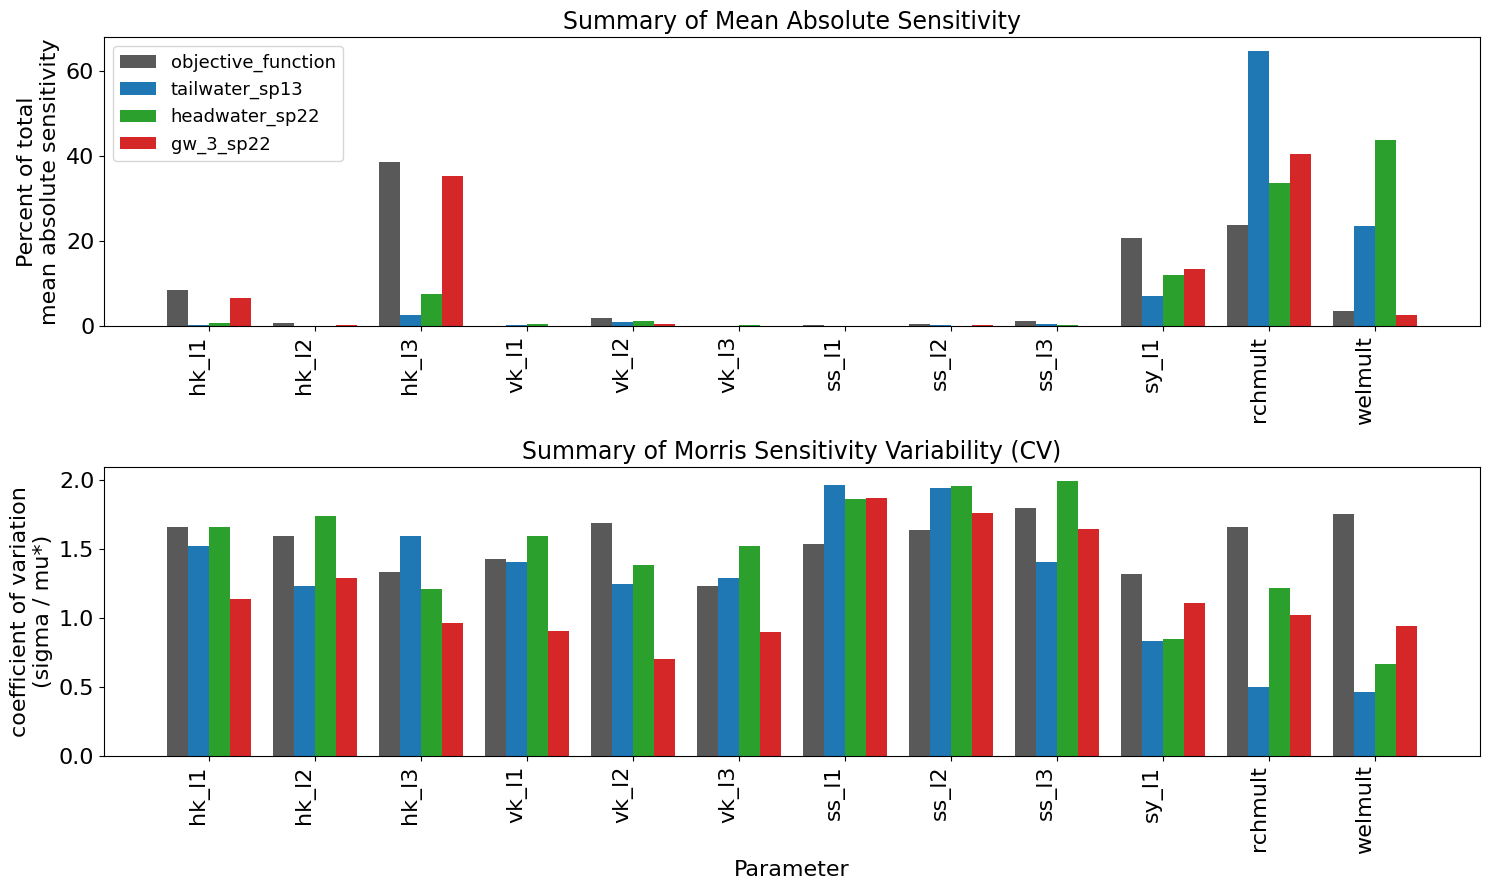

In [20]:
x = np.arange(len(GROUPS)); w = 0.2
colors = ['0.35','tab:blue','tab:green','tab:red']

fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# (A) percent of total mean absolute sensitivity
A = 100 * mean_abs / mean_abs.sum(axis=0)

for k, out in enumerate(OUTPUTS):
    if out in A.columns:
        axes[0].bar(
            x + (k - 1.5) * w,
            A[out].values,
            w,
            label=out,
            color=colors[k]
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels(GROUPS, rotation=90, ha='right', fontsize=16)
axes[0].set_ylabel('Percent of total\nmean absolute sensitivity', fontsize=16)
axes[0].set_title('Summary of Mean Absolute Sensitivity', fontsize=17)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].legend(fontsize=13, loc='upper left')

# (B) coefficient of variation
for k, out in enumerate(OUTPUTS):
    if out in cv.columns:
        axes[1].bar(
            x + (k - 1.5) * w,
            cv[out].values,
            w,
            label=out,
            color=colors[k]
        )

axes[1].set_xticks(x)
axes[1].set_xticklabels(GROUPS, rotation=90, ha='right', fontsize=16)
axes[1].set_xlabel('Parameter', fontsize=16)
axes[1].set_ylabel('coefficient of variation\n(sigma / mu*)', fontsize=16)
axes[1].set_title('Summary of Morris Sensitivity Variability (CV)', fontsize=17)
axes[1].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()

| Purpose                                     | Priority Parameters              | Interpretation                                                                                                         |
| ------------------------------------------- | -------------------------------- | ---------------------------------------------------------------------------------------------------------------------- |
| Calibration against historical observations | `hk_l3`, `rchmult`, `sy_l1`      | hk_l3 properties and rch conditions are important for reproducing observed conditions.       |
| Downstream prediction                       | `rchmult`, followed by `welmult` | rch and water useage primarily controls downstream responses.                                    |
| Upstream dry-period prediction              | `welmult`, `rchmult`             | rch and water useage are important, although their effects depend on model conditions.                                 |
| Future groundwater-level prediction         | `rchmult`, `hk_l3`               | Future GWL depend on both rch input and hk-l3. |



| Top Chart | Bottom Chart | Interpretation                                                                           |
| --------- | ------------ | ---------------------------------------------------------------------------------------- |
| High      | Low          | **A key variable with the most reliable and consistent influence**                       |
| High      | High         | **Important, but likely affected by nonlinearity and/or interactions with other parameters** |
| Low       | Low          | Consistently has little influence                                                        |
| Low       | High         | Usually has little influence, although it may matter under specific conditions           |


ex)
| Output               | Importance in the Top chart | CV in the Bottom chart | Interpretation                                                                           |
| -------------------- | --------------------------: | ---------------------: | ---------------------------------------------------------------------------------------- |
| `objective_function` |                     Highest |                   ~1.3 | Important, but its effect on calibration changes depending on the parameter combination. |
| `gw_3_sp22`          |                        High |                  ~0.95 | Important, with moderate dependence on model conditions.                                 |
| `tailwater_sp13`     |                         Low |                   ~1.6 | Has a small and unstable influence.                                                      |
| `headwater_sp22`     |                    Moderate |                   ~1.2 | Its influence varies depending on model conditions.                                      |

the most important parameter for matching historical obs, but the magnitude of its influence changes depending on the combination of other para.
